# Analysis of Homelessness in Maryland

## Aayushi Roy

# 1. Introduction 

On a single night in January 2019, approximately [567,715 people](https://endhomelessness.org/homelessness-in-america/homelessness-statistics/state-of-homelessness-2020/) in the United States and 6,561 people in Maryland specifically were homeless. In Maryland, that's about 11 out of every 10,000 people who were homeless. It goes without saying that homelessness is an extremely pressing issue in our society, and the onset of COVID-19 has only made it worse. 

In this tutorial, we'll be dividing Maryland into its Continuums of Care (CoC), which are local planning bodies that coordinate homelessness services for particular geographic regions. We'll look at trends across these CoCs in terms of change in homelessness rates over time, homelessness rates in 2019 compared to income and cost of living, and the number of beds available.

# 2. Data Collection

In [168]:
import pandas as pd #pandas
import requests #web scraping
from bs4 import BeautifulSoup #prettify content
import matplotlib.pyplot as plt # for plotting
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Maryland has 16 Continuums of Care, most of them separated by county with a few exceptions. The Mid Shore CoC contains Kent, Queen Anne's, Caroline, and Talbot county. The Lower Shore contains Dorchester, Wicomico, Worcester, and Somerset county. And the Southern Maryland CoC contains Charles, Calvert, and St. Mary's county. 

Every year, the United States Department of Housing and Urban Development (HUD) puts out an Annual Homeless Assessment Report. [This report](https://www.huduser.gov/portal/sites/default/files/pdf/2019-AHAR-Part-1.pdf) details the key findings regarding 2019 national, state, and CoC-level estimates of homelessness. HUD also provides Point-In-Time (PIT) counts, which are annual counts of both sheltered and unsheltered people experiencing homelessness taken on one night in January, and Housing Inventory Counts (HIC), or a point-in-time inventory of beds and units at the following link: https://www.hudexchange.info/resource/5948/2019-ahar-part-1-pit-estimates-of-homelessness-in-the-us/

So first, we download the Excel files for the 2007 - 2019 Point-In-Time Estimates by CoC and the 2007 - 2019 Housing Inventory Count by CoC. Since each year is on a different sheet in the Excel files and the data for 2019 is on the first sheet, when we import the data as dataframes, we'll lose the data for the other years. We want to take a look at how homelessness rates have changed overtime, so I made another Excel file with the Overall Homeless count per year from 2007 to 2019, which can be found [here](https://github.com/aroy2530/aroy2530.github.io/blob/master/2007-2019-HIC-by-CoC-Overall.xlsx).

Next, we read in the data as Pandas dataframes to start tidying the data. You'll notice that we need to specify "openpyxl" as our engine. This is because XLRD no longer supports opening anything other than XLS files.

In [156]:
pit = pd.read_excel("2019-Point-in-Time-Estimates-by-CoC.xlsx", engine="openpyxl")
hic = pd.read_excel("2019-Housing-Inventory-Count-by-CoC.xlsx", engine="openpyxl")
hic_overall = pd.read_excel("2007-2019-HIC-by-CoC-Overall.xlsx", engine="openpyxl")
pit.head()

,CoC Number,CoC Name,CoC Category,"Overall Homeless, 2019","Overall Homeless - Under 18, 2019","Overall Homeless - Age 18 to 24, 2019","Overall Homeless - Over 24, 2019","Overall Homeless - Female, 2019","Overall Homeless - Male, 2019","Overall Homeless - Transgender, 2019",...,"Overall Homeless Parenting Youth Age 18-24, 2019","Sheltered ES Homeless Parenting Youth Age 18-24, 2019","Sheltered TH Homeless Parenting Youth Age 18-24, 2019","Sheltered Total Homeless Parenting Youth Age 18-24, 2019","Unsheltered Homeless Parenting Youth Age 18-24, 2019","Overall Homeless Children of Parenting Youth, 2019","Sheltered ES Homeless Children of Parenting Youth, 2019","Sheltered TH Homeless Children of Parenting Youth, 2019","Sheltered Total Homeless Children of Parenting Youth, 2019","Unsheltered Homeless Children of Parenting Youth, 2019"
0,AK-500,Anchorage CoC,Other Largely Urban CoC,1111.0,193.0,132.0,786.0,422.0,685.0,4.0,...,17.0,5.0,12.0,17.0,0.0,24.0,12.0,12.0,24.0,0.0
1,AK-501,Alaska Balance of State CoC,Largely Rural CoC,796.0,142.0,72.0,582.0,339.0,452.0,2.0,...,3.0,1.0,2.0,3.0,0.0,3.0,1.0,2.0,3.0,0.0
2,AL-500,"Birmingham/Jefferson, St. Clair, Shelby Counti...",Largely Suburban CoC,981.0,108.0,72.0,801.0,358.0,622.0,1.0,...,7.0,0.0,7.0,7.0,0.0,7.0,0.0,7.0,7.0,0.0
3,AL-501,Mobile City & County/Baldwin County CoC,Other Largely Urban CoC,505.0,110.0,18.0,377.0,216.0,289.0,0.0,...,4.0,2.0,2.0,4.0,0.0,6.0,3.0,3.0,6.0,0.0
4,AL-502,Florence/Northwest Alabama CoC,Largely Rural CoC,390.0,152.0,8.0,230.0,217.0,172.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [157]:
hic.head()

,Unnamed: 0,"Total Beds (ES, TH, SH)",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Other Permanent Housing (OPH),Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76
0,CoC Number,"Total Year-Round Beds (ES, TH, SH)","Total Non-DV Year-Round Beds (ES, TH, SH)","Total HMIS Year-Round Beds (ES, TH, SH)",HMIS Participation Rate for Year-Round Beds (E...,Total Year-Round Beds (ES),Total Year-Round Beds (TH),Total Year-Round Beds (SH),"Total Units for Households with Children (ES, ...","Total Beds for Households with Children (ES, T...",...,Total Year-Round Beds (OPH),Total Non-DV Year-Round Beds (OPH),Total HMIS Year-Round Beds (OPH),HMIS Participation Rate for Year-Round Beds (OPH),Total Units for Households with Children (OPH),Total Beds for Households with Children (OPH),Total Beds for Households without Children (OPH),Total Beds for Households with only Children (...,Dedicated Veteran Beds (OPH),Dedicated Youth Beds (OPH)
1,AK-500,1033,961,855,0.8277,799,234,0,92,396,...,71,71,71,1,0,0,71,0,0,0
2,AK-501,845,525,478,0.5657,575,270,0,119,281,...,0,0,0,.,0,0,0,0,0,0
3,AL-500,827,727,580,0.7013,516,277,34,95,279,...,0,0,0,.,0,0,0,0,0,0
4,AL-501,394,311,291,0.7386,261,133,0,58,200,...,0,0,0,.,0,0,0,0,0,0


In [158]:
hic_overall.head()

,CoC Number,CoC Name,Overall Homeless,Year,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 532,Unnamed: 533,Unnamed: 534,Unnamed: 535,Unnamed: 536,Unnamed: 537,Unnamed: 538,Unnamed: 539,Unnamed: 540,Unnamed: 541
0,MD-500,Cumberland/Allegany County CoC,145,2019,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MD-501,Baltimore CoC,2294,2019,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MD-502,Harford County CoC,228,2019,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MD-503,Annapolis/Anne Arundel County CoC,302,2019,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MD-504,Howard County CoC,201,2019,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We also want to look at income per capita and cost of living for each CoC. We can go to the United States Bureau of Economic Analysis to get the real personal income by county in Maryland in 2019 (https://apps.bea.gov/iTable/iTable.cfm?reqid=70&step=1&isuri=1&acrdn=6#reqid=70&step=1&isuri=1&acrdn=6). We can then download the data as a CSV file and store it as a dataframe.

In [176]:
income = pd.read_csv("MDIncome2019.csv")
income

,"CAINC1 Personal Income Summary: Personal Income, Population, Per Capita Personal Income",Unnamed: 1,Unnamed: 2
0,Per capita personal income (Dollars) 2/,NaN,NaN
1,Bureau of Economic Analysis,NaN,NaN
2,County,NaN,NaN
3,GeoFips,GeoName,2019.0
4,24000,Maryland,64640.0
5,24001,"Allegany, MD",41454.0
6,24003,"Anne Arundel, MD",69035.0
7,24005,"Baltimore, MD",62976.0
8,24009,"Calvert, MD",63976.0
9,24011,"Caroline, MD",46883.0


To get the cost of living per CoC, we'll use BestPlaces (https://www.bestplaces.net/find/county.aspx?st=maryland) to get the cost of living indices per county in Maryland. On BestPlaces, each county's cost of living can be easily reached by replacing the name of the county at the end of the URL. We can automate gathering data for every county in Maryland as seen below.

In [160]:
# list of counties to iterate through
counties = ["Allegany", "Anne Arundel", "Baltimore", "Calvert", "Caroline", "Carroll", "Cecil", "Charles", 
            "Dorchester", "Frederick", "Garrett", "Harford", "Howard", "Kent", "Montgomery", "Prince_George's", 
            "Queen_Anne's", "St._Mary's", "Somerset", "Talbot", "Washington", "Wicomico", "Worcester", "Baltimore_City"]

# where cost of living will be deposited
df_cost = []

for county in counties:
    # where data from each county's table will be deposited
    county_data = []

    # GET request
    r = requests.get("https://www.bestplaces.net/cost_of_living/county/maryland/"+county, verify=False)
    soup = BeautifulSoup(r.content, "html.parser")
    tbl = soup.find("table", id="mainContent_dgCostOfLiving")
    
    for tr in tbl.select('tr'):
        try:
            # extract first column in table
            county_data.append (tr.select('td')[1].text)
        except:
            pass
        
    # extract cost of living index
    df_cost.append(county_data[1])
    
df_cost

['76.9',
 '118.5',
 '105.7',
 '123.9',
 '92.6',
 '115.2',
 '105.8',
 '114.7',
 '86.4',
 '113.3',
 '87',
 '109.2',
 '134.8',
 '94.7',
 '139.4',
 '121.3',
 '121.5',
 '111.3',
 '81.1',
 '108.8',
 '94.5',
 '88.5',
 '103.7',
 '89.3']

## Tidying the Data

We'll start with the HIC from 2007-2019. This has every CoC number, the name, the overall homeless count, and the year the count was taken in. All we need to do to tidy this one is remove the excess columns on the right after "Year".

In [161]:
# Keep all rows, keep all columns up to Year
hic_overall = hic_overall.loc[:, :"Year"]
hic_overall

,CoC Number,CoC Name,Overall Homeless,Year
0,MD-500,Cumberland/Allegany County CoC,145,2019
1,MD-501,Baltimore CoC,2294,2019
2,MD-502,Harford County CoC,228,2019
3,MD-503,Annapolis/Anne Arundel County CoC,302,2019
4,MD-504,Howard County CoC,201,2019
...,...,...,...,...
203,MD-511,Mid-Shore Regional CoC,311,2007
204,MD-512,Hagerstown/Washington County CoC,212,2007
205,MD-513,"Wicomico, Somerset, Worcester Counties CoC",215,2007
206,MD-600,Prince George's County CoC,1168,2007


Alright, next let's tackle the PIT dataframe. We only want to look at the data for Maryland, so we slice our dataframe to only contain rows 163 through 178. There are 542 columns in this dataframe, that's a lot! If we take a closer look at the data, we'll notice that it's the overall homeless count broken down into many subcategories including age, gender, ethnicity, sheltered vs unsheltered, household type, and project type. Project types are the different programs that provide temporary and permanent housing, such as Emergency Shelters (ES), Transitional Housing (TH), Safe Haven (SH), Rapid Rehousing (RRH), Permanent Supportive Housing (PSH), and Other Permanent Housing (OPH). 

We'll be focusing on the Overall Homeless, Sheltered Total Homeless, and Unsheltered Homeless columns. Let's go ahead and extract those columns, along with CoC number and name, for the PIT dataframe.

In [162]:
# Keep only Maryland CoC rows
pit = pit[163:179]
# Keep only necessary columns
pit = pit[["CoC Number", "CoC Name", "Overall Homeless, 2019", 
           "Sheltered Total Homeless, 2019", "Unsheltered Homeless, 2019"]]
pit

,CoC Number,CoC Name,"Overall Homeless, 2019","Sheltered Total Homeless, 2019","Unsheltered Homeless, 2019"
163,MD-500,Cumberland/Allegany County CoC,145.0,108.0,37.0
164,MD-501,Baltimore CoC,2294.0,1914.0,380.0
165,MD-502,Harford County CoC,228.0,205.0,23.0
166,MD-503,Annapolis/Anne Arundel County CoC,302.0,241.0,61.0
167,MD-504,Howard County CoC,201.0,129.0,72.0
168,MD-505,Baltimore County CoC,735.0,486.0,249.0
169,MD-506,Carroll County CoC,144.0,121.0,23.0
170,MD-507,Cecil County CoC,126.0,104.0,22.0
171,MD-508,"Charles, Calvert, St.Mary's Counties CoC",306.0,192.0,114.0
172,MD-509,Frederick City & County CoC,286.0,208.0,78.0


Now we'll look at the 2019 HIC data. Once again, we only want the data for the Maryland CoCs. However, since we'll only be looking at the Total Year-Round Beds in 2019, we can merge the PIT dataframe with that column in the HIC dataframe. We can also then rename the dataframe to md_2019.

In [163]:
# Keep only Maryland CoC rows and Total Beds column
total_beds = hic["Total Beds (ES, TH, SH)"][164:180]

# Change indices for total_beds to match pit to allow for smoothly adding new column
pit["Total Beds"] = total_beds.iloc[:].values

md_2019 = pit
md_2019

,CoC Number,CoC Name,"Overall Homeless, 2019","Sheltered Total Homeless, 2019","Unsheltered Homeless, 2019",Total Beds
163,MD-500,Cumberland/Allegany County CoC,145.0,108.0,37.0,124
164,MD-501,Baltimore CoC,2294.0,1914.0,380.0,2154
165,MD-502,Harford County CoC,228.0,205.0,23.0,169
166,MD-503,Annapolis/Anne Arundel County CoC,302.0,241.0,61.0,153
167,MD-504,Howard County CoC,201.0,129.0,72.0,113
168,MD-505,Baltimore County CoC,735.0,486.0,249.0,582
169,MD-506,Carroll County CoC,144.0,121.0,23.0,98
170,MD-507,Cecil County CoC,126.0,104.0,22.0,121
171,MD-508,"Charles, Calvert, St.Mary's Counties CoC",306.0,192.0,114.0,159
172,MD-509,Frederick City & County CoC,286.0,208.0,78.0,252


For the income dataframe, we'll drop the first and last few rows. We'll also drop the first column, rename the other two columns, and add in the data from df_cost to make a finance dataframe. 

If you will recall, some of our counties are grouped together for CoCs. We'll take an average income and cost of living for those counties and add them to our dataframe, deleting the counties that go in those CoCs.

In [179]:
# Drop unnecessary column and rows
income.drop([0, 1, 2, 3, 4, 29, 30, 31, 32, 33], inplace=True)
income.drop(columns=["CAINC1 Personal Income Summary: Personal Income, Population, Per Capita Personal Income"], 
            inplace=True)

# Rename columns
income.rename(columns={"Unnamed: 1": "CoC", "Unnamed: 2": "Income Per Capita"}, inplace=True)

# Convert cost of living values to floats
# Change indices for total_beds to match pit to allow for smoothly adding new column
df_cost = pd.to_numeric(pd.Series(df_cost))
income["Cost of Living Index"] = df_cost.iloc[:].values

finances = income.reset_index(drop=True)

## Now we combine counties
# Mid Shore (Kent, Queen Anne's, Caroline, Talbot)
ms_income = (finances.iloc[13]["Income Per Capita"] + finances.iloc[16]["Income Per Capita"] + 
    finances.iloc[4]["Income Per Capita"] + finances.iloc[19]["Income Per Capita"])/4
ms_CoL = (finances.iloc[13]["Cost of Living Index"] + finances.iloc[16]["Cost of Living Index"] + 
    finances.iloc[4]["Cost of Living Index"] + finances.iloc[19]["Cost of Living Index"])/4
finances.loc[24]=((["Mid Shore", ms_income, ms_CoL]))

# Lower Shore (Dorchester, Wicomico, Somerset, Worcester)
ls_income = (finances.iloc[8]["Income Per Capita"] + finances.iloc[21]["Income Per Capita"] + 
    finances.iloc[18]["Income Per Capita"] + finances.iloc[22]["Income Per Capita"])/4
ls_CoL = (finances.iloc[8]["Cost of Living Index"] + finances.iloc[21]["Cost of Living Index"] + 
    finances.iloc[18]["Cost of Living Index"] + finances.iloc[22]["Cost of Living Index"])/4
finances.loc[25]=((["Lower Shore", ls_income, ls_CoL]))

# Southern MD (Charles, Calvert, St. Mary's)
sm_income = (finances.iloc[7]["Income Per Capita"] + finances.iloc[3]["Income Per Capita"] + 
    finances.iloc[17]["Income Per Capita"])/3
sm_CoL = (finances.iloc[7]["Cost of Living Index"] + finances.iloc[3]["Cost of Living Index"] + 
    finances.iloc[17]["Cost of Living Index"])/3
finances.loc[26]=((["Southern MD", sm_income, sm_CoL]))

finances.drop([13, 16, 4, 19, 8, 21, 18, 22, 7, 3, 17], inplace=True)
finances = finances.reindex([0, 23, 11, 1, 12,2,5,6,26,9,10,24,20,25,15,14])
finances

,CoC,Income Per Capita,Cost of Living Index
0,"Allegany, MD",41454.000000,76.900000
23,"Baltimore (Independent City), MD",53378.000000,89.300000
11,"Harford, MD",60266.000000,109.200000
1,"Anne Arundel, MD",69035.000000,118.500000
12,"Howard, MD",79253.000000,134.800000
2,"Baltimore, MD",62976.000000,105.700000
5,"Carroll, MD",64288.000000,115.200000
6,"Cecil, MD",49749.000000,105.800000
26,Southern MD,60110.666667,116.633333
9,"Frederick, MD",64147.000000,113.300000


# 3. Data Exploration/Graph Visualization

Great! Our data is all tidied up and in three dataframes: hic_overall, which contains the Overall Homeless count per Maryland CoC from 2007 to 2019, md_2019, which has the total overall homeless count, sheltered count, unsheltered count, and total bed count, and finances, which has the income per capita and cost of living per CoC. 

Let's start by visualizing the total number of homeless people by CoC via a stacked bar chart, using the data visualization library [matplotlib](https://matplotlib.org/). As a refresher, we'll be using the md_2019 dataframe below to do this.

In [165]:
md_2019

,CoC Number,CoC Name,"Overall Homeless, 2019","Sheltered Total Homeless, 2019","Unsheltered Homeless, 2019",Total Beds
163,MD-500,Cumberland/Allegany County CoC,145.0,108.0,37.0,124
164,MD-501,Baltimore CoC,2294.0,1914.0,380.0,2154
165,MD-502,Harford County CoC,228.0,205.0,23.0,169
166,MD-503,Annapolis/Anne Arundel County CoC,302.0,241.0,61.0,153
167,MD-504,Howard County CoC,201.0,129.0,72.0,113
168,MD-505,Baltimore County CoC,735.0,486.0,249.0,582
169,MD-506,Carroll County CoC,144.0,121.0,23.0,98
170,MD-507,Cecil County CoC,126.0,104.0,22.0,121
171,MD-508,"Charles, Calvert, St.Mary's Counties CoC",306.0,192.0,114.0,159
172,MD-509,Frederick City & County CoC,286.0,208.0,78.0,252


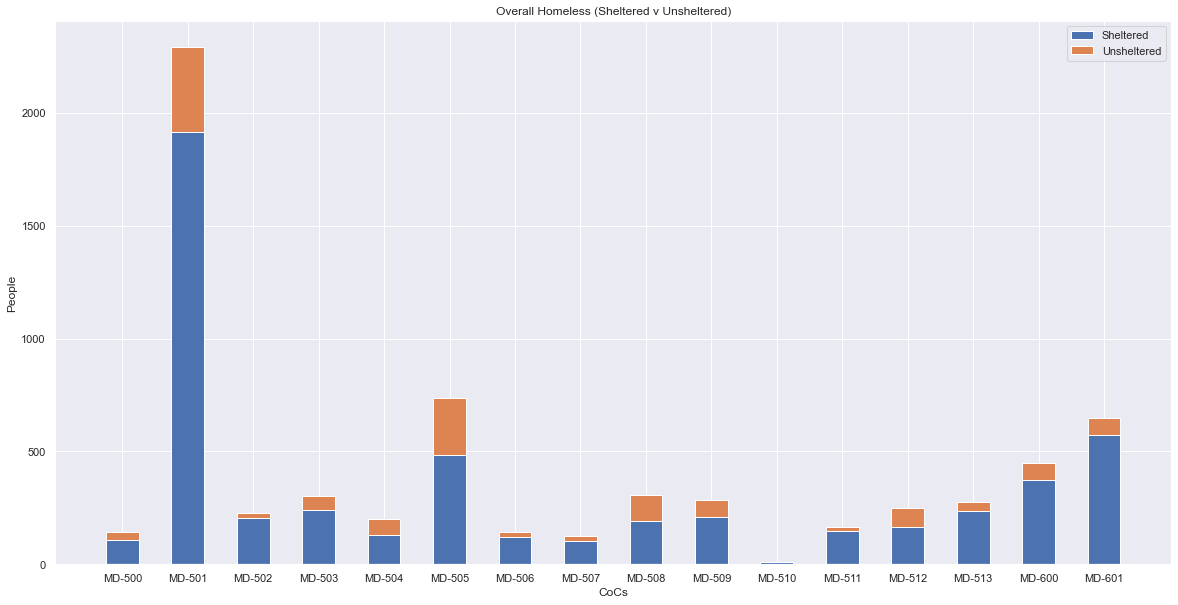

In [167]:
fig, ax = plt.subplots(figsize=(20, 10))
width = 0.50

ax.bar(md_2019["CoC Name"], md_2019["Sheltered Total Homeless, 2019"], width, label = "Sheltered")
ax.bar(md_2019["CoC Name"], md_2019["Unsheltered Homeless, 2019"], width, bottom=md_2019["Sheltered Total Homeless, 2019"],
       label = "Unsheltered")

ax.set_ylabel("People")
ax.set_xlabel("CoCs")
x = md_2019["CoC Number"]
xi = list(range(len(x)))
plt.xticks(xi, x)
plt.title("Overall Homeless (Sheltered v Unsheltered)")
ax.legend()

plt.show()

Interesting, it looks like the Baltimore CoC has the highest rate of homeless people, but then again, Baltimore City is one of the most populated areas! Most of the homeless in 2019 were sheltered, which is good to hear. Let's take a look at the how the income per capita for these CoCs aligns with the homelessness rate. We'll use [seaborn](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) to do this.

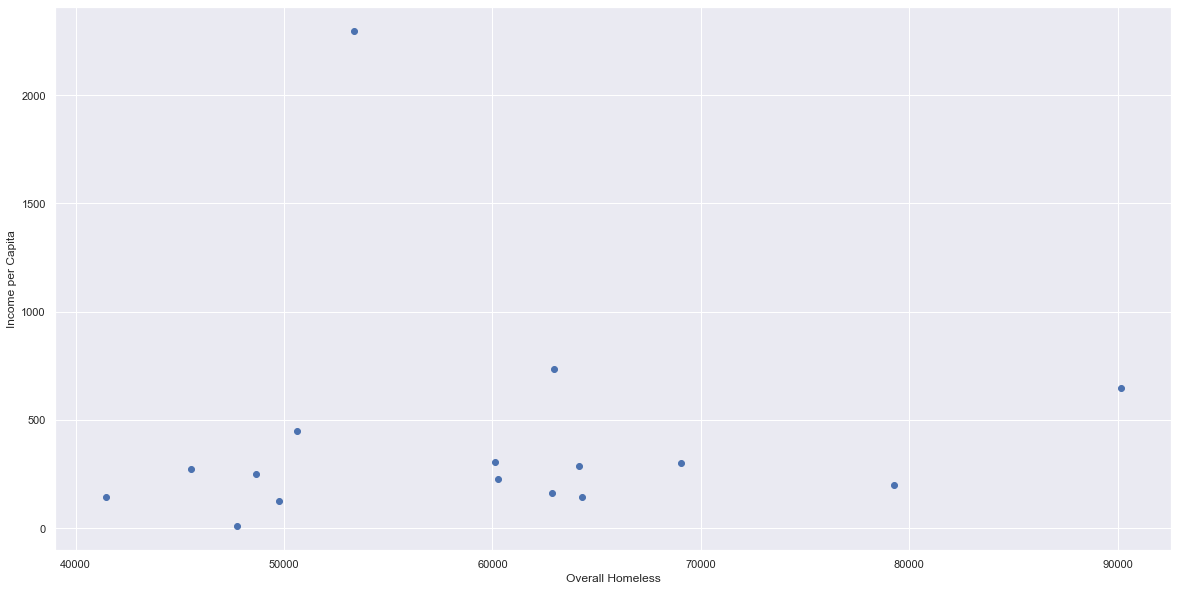

In [202]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.set()
plt.scatter(finances["Income Per Capita"], md_2019["Overall Homeless, 2019"])
plt.ylabel("Overall Homeless")
plt.xlabel("Income per Capita")
plt.show()

There appears to be somewhat of a correlation between the overall homeless population and the income per capita. Maybe we'll have better luck with the cost of living?

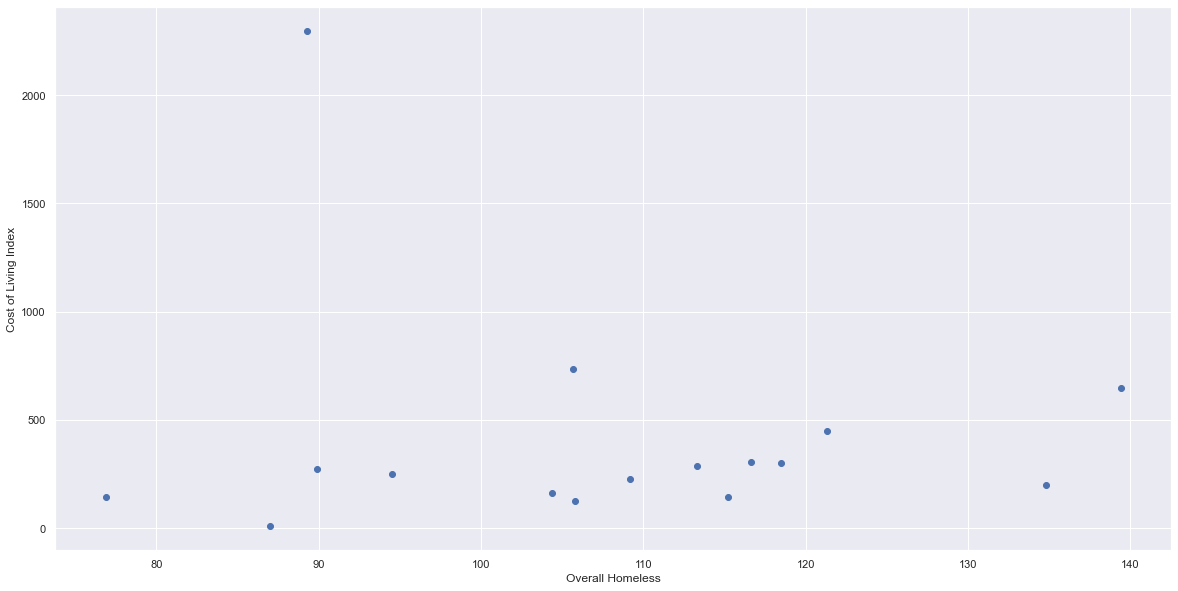

In [201]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.set()
plt.scatter(finances["Cost of Living Index"],md_2019["Overall Homeless, 2019"])
plt.ylabel("Overall Homeless")
plt.xlabel("Cost of Living Index")
plt.show()

Still not very strong, but let's try applying linear regression. 

In [206]:
!pip install sklearn
from sklearn import linear_model #for linear regression
clf = linear_model.LinearRegression()
clf.fit(finances["Cost of Living Index"], md_2019["Overall Homeless, 2019"])
predicted = clf.predict(finances["Cost of Living Index"])

plt.plot(finances["Cost of Living Index"],predicted)
plt.title("Cost vs Homeless Population")
plt.xlabel("Cost")b
plt.ylabel("People")
plt.show()

  Running setup.py install for sklearn: started
    Running setup.py install for sklearn: finished with status 'done'


You should consider upgrading via the 'python -m pip install --upgrade pip' command.


ValueError: Expected 2D array, got 1D array instead:
array=[ 76.9         89.3        109.2        118.5        134.8
 105.7        115.2        105.8        116.63333333 113.3
  87.         104.4         94.5         89.925      121.3
 139.4       ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

# 4. Conclusion 

Overall, it appears that as the income and cost of living per CoC increases, the amount of homeless individuals also increases.